In [24]:
import pandas as pd
import matplotlib.pyplot as plt


In [25]:
df=pd.read_csv('\\Users\\ASUS\\.vscode\\Superstore Analysis\\super_data\\super_cleaned.csv')

In [26]:
df["Total Amount"]=df["Sales"]*df["Quantity"]

In [46]:
df[(df["Product ID"]=="OFF-ST-10003479") &(df["Quantity"]==2 )]

,Unnamed: 0,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Total Amount
42,42,43,CA-2016-101343,2016-07-17,2016-07-22,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,...,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.894,155.76
3404,3404,3405,CA-2015-152527,2015-10-17,2015-10-17,Same Day,CM-12190,Charlotte Melton,Consumer,United States,...,West,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.894,155.76


In [28]:
df.isnull().sum()

Unnamed: 0       0
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Total Amount     0
dtype: int64

In [29]:
df.describe()

,Unnamed: 0,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Total Amount
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4996.500000,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,1149.495905
std,2885.163629,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,3898.666090
min,0.000000,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.444000
25%,2498.250000,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,48.693500
50%,4996.500000,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,183.680000
75%,7494.750000,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,763.201500
max,9993.000000,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,135830.880000


In [30]:
df.dtypes

Unnamed: 0         int64
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Total Amount     float64
dtype: object

In [31]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Unnamed: 0     9994 non-null   int64         
 1   Row ID         9994 non-null   int64         
 2   Order ID       9994 non-null   str           
 3   Order Date     9994 non-null   datetime64[us]
 4   Ship Date      9994 non-null   datetime64[us]
 5   Ship Mode      9994 non-null   str           
 6   Customer ID    9994 non-null   str           
 7   Customer Name  9994 non-null   str           
 8   Segment        9994 non-null   str           
 9   Country        9994 non-null   str           
 10  City           9994 non-null   str           
 11  State          9994 non-null   str           
 12  Postal Code    9994 non-null   int64         
 13  Region         9994 non-null   str           
 14  Product ID     9994 non-null   str           
 15  Category       9994 non-null   s

In [34]:
df.groupby("Region")["Sales"].sum()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Sales, dtype: float64

In [35]:
df.groupby("State")["Sales"].sum()

State
Alabama                  19510.6400
Arizona                  35282.0010
Arkansas                 11678.1300
California              457687.6315
Colorado                 32108.1180
Connecticut              13384.3570
Delaware                 27451.0690
District of Columbia      2865.0200
Florida                  89473.7080
Georgia                  49095.8400
Idaho                     4382.4860
Illinois                 80166.1010
Indiana                  53555.3600
Iowa                      4579.7600
Kansas                    2914.3100
Kentucky                 36591.7500
Louisiana                 9217.0300
Maine                     1270.5300
Maryland                 23705.5230
Massachusetts            28634.4340
Michigan                 76269.6140
Minnesota                29863.1500
Mississippi              10771.3400
Missouri                 22205.1500
Montana                   5589.3520
Nebraska                  7464.9300
Nevada                   16729.1020
New Hampshire         

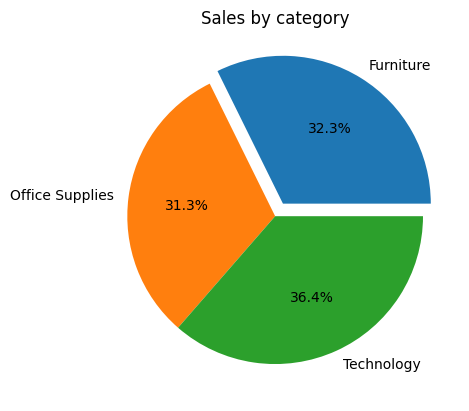

In [36]:
Sales_by_category=(df.groupby("Category")["Sales"].sum())
plt.pie(Sales_by_category,labels=Sales_by_category.index
        ,autopct="%1.1f%%",explode=(0.1,0,0))
plt.title("Sales by category")
plt.show()

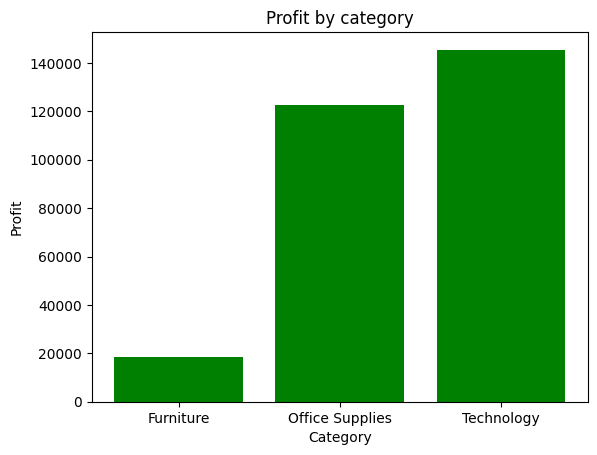

In [37]:
total_category=df["Category"].unique()
profit_by_category=df.groupby("Category")["Profit"].sum()

plt.bar(total_category,profit_by_category,color="green",)
plt.title("Profit by category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

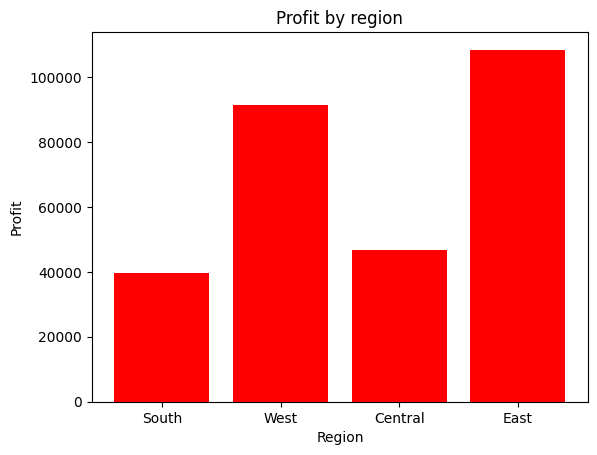

In [38]:
profit_by_region=df.groupby("Region")["Profit"].sum()
unique_region=df["Region"].unique()

plt.bar(unique_region,profit_by_region,color="red")
plt.title("Profit by region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()


In [39]:
product_profit=df.groupby("Product Name")["Profit"].sum()
top_product=product_profit.idxmax()
amount=product_profit.max()
print(f"The most profitable product is {top_product} profit={amount}")

The most profitable product is Canon imageCLASS 2200 Advanced Copier profit=25199.928


In [40]:
df["Segment"].value_counts()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

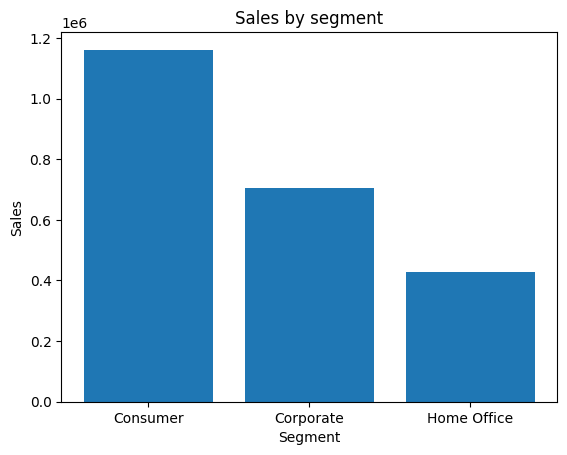

In [41]:
segment_sales=df.groupby("Segment")["Sales"].sum()
unique_segment=df["Segment"].unique()
plt.bar(unique_segment,segment_sales)
plt.xlabel("Segment")
plt.ylabel("Sales") 
plt.title("Sales by segment")
plt.show()

In [42]:
sales_by_year=df.groupby(df["Order Date"].dt.year)["Sales"].sum()
sales_by_year.mean()

np.float64(574300.215075)

In [43]:
df["Customer ID"].nunique()

793

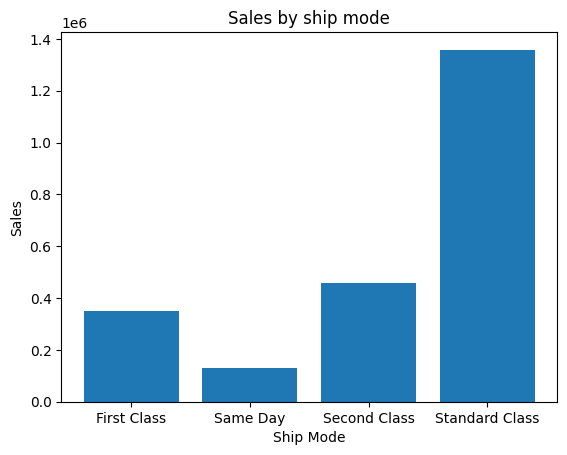

In [44]:
sales_by_shipmode=df.groupby("Ship Mode")["Sales"].sum()
shipmodes=sales_by_shipmode.index
plt.bar(shipmodes,sales_by_shipmode)
plt.xlabel("Ship Mode")
plt.ylabel("Sales")
plt.title("Sales by ship mode")
plt.show()

In [47]:
df.drop(["Unnamed: 0"],axis=1,inplace=True)

In [ ]:
df.drop(["Total Amount"],axis=1,inplace=True)

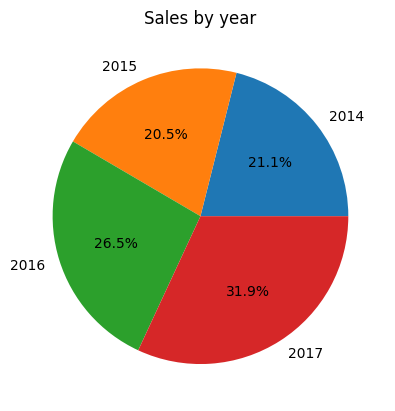

In [ ]:
sales_by_year=df.groupby(df["Order Date"].dt.year)["Sales"].sum()
plt.pie(sales_by_year,labels=sales_by_year.index
        ,autopct="%1.1f%%")
plt.title("Sales by year")
plt.show()

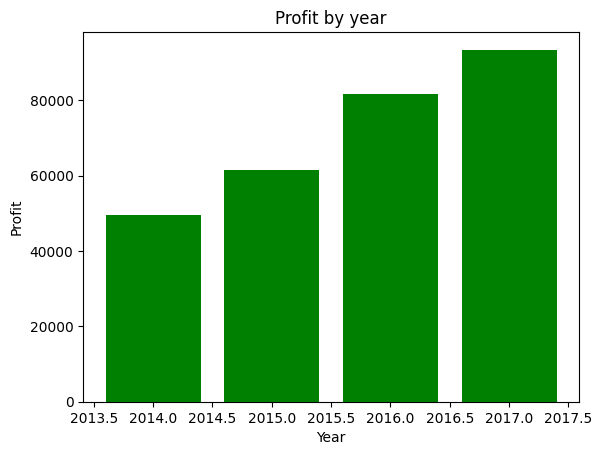

In [ ]:
Profit_by_year=df.groupby(df["Order Date"].dt.year)["Profit"].sum()
plt.bar(Profit_by_year.index,Profit_by_year,color="green")
plt.xlabel("Year")  
plt.ylabel("Profit")
plt.title("Profit by year")
plt.show()

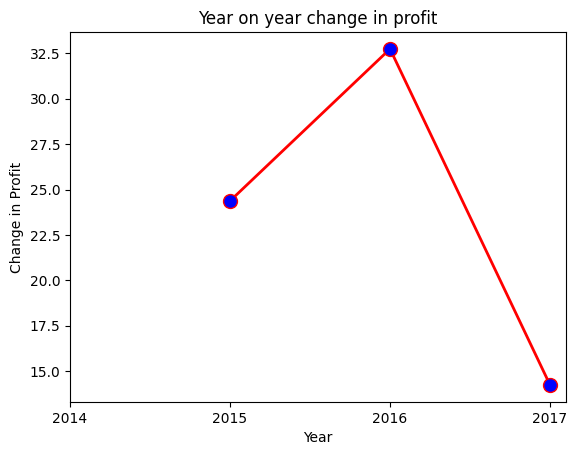

In [ ]:
yoy_change=Profit_by_year.pct_change()*100
plt.plot(yoy_change,color="red",marker="o",markerfacecolor="blue"
         ,markersize=10,linewidth=2,linestyle="-")
plt.xlabel("Year")
plt.ylabel("Change in Profit")
plt.title("Year on year change in profit")
plt.xticks(yoy_change.index)
plt.show()

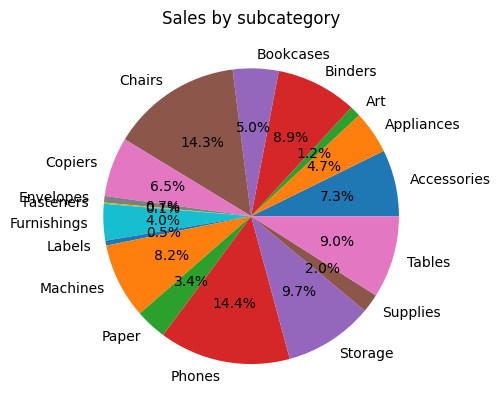

In [ ]:
Sales_by_subcategory=(df.groupby("Sub-Category")["Sales"].sum())
plt.pie(Sales_by_subcategory,labels=Sales_by_subcategory.index
        ,autopct="%1.1f%%")
plt.title("Sales by subcategory")
plt.show()

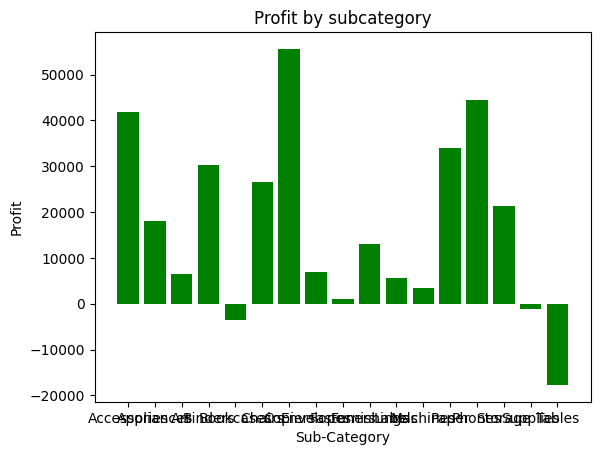

In [ ]:
Pofit_by_subcategory=df.groupby("Sub-Category")["Profit"].sum()
plt.bar(Pofit_by_subcategory.index,Pofit_by_subcategory,color="green")
plt.xlabel("Sub-Category")
plt.ylabel("Profit")
plt.title("Profit by subcategory")
plt.show()

In [ ]:
df.to_csv("C:\\Users\\ASUS\\.vscode\\Superstore Analysis\\super_data\\super_cleaned.csv")